In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import sqlite3
from typing import Annotated
from langchain_core.tools import tool
from langchain_experimental.tools import PythonREPLTool
import pandas as pd
from datetime import datetime, timedelta

# Initialize SQLite database with some tables
def init_database():
    conn = sqlite3.connect('warehouse2.db')
    c = conn.cursor()

    # Create tables
    c.execute('''CREATE TABLE IF NOT EXISTS inventory
                 (product_id TEXT PRIMARY KEY,
                  name TEXT,
                  quantity INTEGER,
                  reorder_point INTEGER,
                  unit_price REAL)''')

    c.execute('''CREATE TABLE IF NOT EXISTS orders
                 (order_id TEXT PRIMARY KEY,
                  order_date TIMESTAMP,
                  status TEXT,
                  total_amount REAL)''')

    c.execute('''CREATE TABLE IF NOT EXISTS order_items
                 (order_id TEXT,
                  product_id TEXT,
                  quantity INTEGER,
                  FOREIGN KEY(order_id) REFERENCES orders(order_id),
                  FOREIGN KEY(product_id) REFERENCES inventory(product_id))''')

    # Insert sample data
    c.execute('DELETE FROM inventory')
    c.execute('DELETE FROM orders')
    c.execute('DELETE FROM order_items')

    # Sample inventory
    inventory_data = [
        ('SKU001', 'Gaming Laptop', 45, 20, 999.99),
        ('SKU002', 'Wireless Mouse', 150, 50, 29.99),
        ('SKU003', 'Mechanical Keyboard', 5, 30, 89.99),
        ('SKU004', 'Monitor 27"', 30, 15, 299.99),
        ('SKU005', 'USB-C Hub', 10, 40, 49.99)
    ]
    c.executemany('INSERT INTO inventory VALUES (?,?,?,?,?)', inventory_data)

    # Sample orders
    for i in range(1, 21):  # Create 20 sample orders
        order_id = f'ORD{i:03d}'
        order_date = datetime.now() - timedelta(days=i)
        status = ['Pending', 'Processing', 'Shipped', 'Delivered'][i % 4]
        c.execute('INSERT INTO orders VALUES (?,?,?,?)',
                 (order_id, order_date, status, 0))  # Total will be updated

        # Add 1-3 items to each order
        for j in range(1, (i % 3) + 2):
            product_id = f'SKU{(i + j) % 5 + 1:03d}'
            quantity = (i + j) % 5 + 1
            c.execute('INSERT INTO order_items VALUES (?,?,?)',
                     (order_id, product_id, quantity))

    conn.commit()
    conn.close()

# Initialize the database
init_database()

C:\Users\localadmin\AppData\Local\Temp\ipykernel_11776\1145282960.py:4: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonREPLTool
C:\Users\localadmin\AppData\Local\Temp\ipykernel_11776\1145282960.py:54: DeprecationWarning: The default datetime adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  c.execute('INSERT INTO orders VALUES (?,?,?,?)',


In [3]:
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI
from langchain_experimental.tools import PythonREPLTool

llm = ChatOpenAI(model="gpt-4.1-mini")

# Create database connection
db = SQLDatabase.from_uri("sqlite:///warehouse2.db")

# Create the SQL toolkit
sql_toolkit = SQLDatabaseToolkit(db=db, llm=llm)

# Create tool instances
python_repl = PythonREPLTool()

C:\Users\localadmin\AppData\Local\Temp\ipykernel_11776\630339894.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


In [4]:
from langchain.agents import create_agent

# Create specialized agents with their tools
inventory_agent = create_agent(
    model=llm,
    tools=[python_repl, *sql_toolkit.get_tools()],
    system_prompt="""You are the Inventory Manager.
      You operate in TWO distinct phases depending on where you are in the workflow:

    PHASE 1 - CHECK (called BEFORE OrderProcessor):
    - Query inventory levels and check stock availability for the requested items.
    - Report current quantities and whether stock is sufficient for the order.
    - Do NOT update or deduct any inventory quantities in this phase.
    - End with CONCLUSION: Stock check complete. Item X has Y units available. [Sufficient/Insufficient] for the order.

    PHASE 2 - UPDATE (called AFTER OrderProcessor has confirmed the order):
    - Deduct/update inventory quantities to reflect the fulfilled order.
    - Confirm before and after quantities.
    - End with CONCLUSION: Inventory updated. Item X reduced from A to B units.

    How to determine your phase: Check the conversation history.
    - If you see NO message from OrderProcessor with a CONCLUSION → you are in PHASE 1 (CHECK only, do NOT update).
    - If you see a message from OrderProcessor with a CONCLUSION confirming the order was processed → you are in PHASE 2 (UPDATE inventory).

    Additional Instructions:
    - NEVER ask for confirmation or approval. Proceed autonomously with the task.
    - Do NOT say "Please confirm" or "Shall I proceed" — just do the work.
    - If generating code, make sure the code is correct and returns the expected value.
    - Think properly before generating code and generate all required code at once.
    - Use proper SQL syntax and verify data before any updates.
    - Keep responses focused and concise."""
)

order_agent = create_agent(
    model=llm,
    tools=[python_repl, *sql_toolkit.get_tools()],
    system_prompt="""You are the Order Processor. You handle ONLY the orders domain:
    1. Process new orders (order and order_items records as appropriate)
    2. Update order status and related order fields
    3. Look up order details (orders / order_items only)

    Important Instructions:
    - NEVER ask for confirmation or approval. Proceed autonomously with the task.
    - Do NOT say "Please confirm" or "Shall I proceed" — just do the work.
    - Always end your response with a clear CONCLUSION: stating what you found and any actions taken
    - Do NOT check, verify, or query inventory for stock levels or availability. Do NOT read or write the
      inventory table. If stock sufficiency matters, that was already handled by InventoryManager; use the
      conversation context and proceed only with order-side changes you are allowed to make.
    - Do NOT adjust inventory quantities; InventoryManager owns all inventory mutations.
    - For order updates, confirm the new status
    - Provide specific quantities and order details for order lines only
    - Keep responses focused and concise
    Example format:
    *Analysis/Actions taken*
    CONCLUSION: Order XYZ updated. Status changed from A to B; order line details as described."""
)

analytics_agent = create_agent(
    model=llm,
    tools=[python_repl, *sql_toolkit.get_tools()],
    system_prompt="""You are the Analytics Manager. You can:
    1. Analyze sales trends
    2. Generate inventory reports
    3. Calculate key metrics
    4. Provide recommendations
    - NEVER ask for confirmation or approval. Proceed autonomously with the task.
    - Always end your response with a clear CONCLUSION: stating your findings and recommendations
    - Provide specific numbers and insights
    - Keep responses focused and concise
    - Use clear visualizations when needed

    Example format:
    *Analysis performed*
    CONCLUSION: Analysis shows X trend over Y period. Recommend taking Z action."""
)

In [5]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel

# Create a static system prompt instead of dynamically generating it
system_prompt = """
You are a warehouse operations supervisor managing these workers: InventoryManager, OrderProcessor, AnalyticsManager.
You MUST follow domain boundaries and routing order strictly.

Worker responsibilities:
- InventoryManager: ALL inventory operations — checking stock, availability, and updating/deducting quantities.
  Works in two phases: Phase 1 (check only) before order processing, Phase 2 (update) after order is confirmed.
- OrderProcessor: Creates/updates order records, order items, order status. Does NOT touch inventory tables.
- AnalyticsManager: Reports, trends, metrics, and analysis only.

MANDATORY 4-STEP SEQUENCE for any request to "process order" or "process order AND update inventory":
  Step 1 → InventoryManager  (CHECK stock availability only — no inventory updates yet)
  Step 2 → OrderProcessor    (process/update the order using Step 1 results from conversation context)
  Step 3 → InventoryManager  (UPDATE/deduct inventory based on the confirmed order from Step 2)
  Step 4 → FINISH

LOOP PREVENTION — follow these rules exactly:
- If InventoryManager has posted a CONCLUSION about stock CHECK and OrderProcessor has NOT yet run → route to OrderProcessor.
- If OrderProcessor has posted a CONCLUSION confirming the order → route to InventoryManager for the inventory UPDATE.
- If InventoryManager has posted a CONCLUSION about an inventory UPDATE (after OrderProcessor already ran) → respond with FINISH.
- NEVER route to the same worker twice in a row unless it is the planned second call to InventoryManager (Step 3 above).
- If you are unsure whether a worker has completed its task, look for the word CONCLUSION in its latest message.

For inventory-only requests (no order processing): InventoryManager → FINISH
For order-status/lookup-only requests:             OrderProcessor → FINISH
For analytics/reporting requests:                  AnalyticsManager → FINISH
"""

options = ["FINISH", "InventoryManager", "OrderProcessor", "AnalyticsManager"]

# Set up the supervisor prompt with the static system prompt
prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    MessagesPlaceholder(variable_name="messages"),
    ("system", """Review the conversation above carefully.
Identify which steps are already COMPLETED by looking for CONCLUSION statements in each worker's messages.
Based on the mandatory sequence rules, decide who should act next.
Do NOT repeat a worker that has already completed its current-phase task.
Who should act next? Or should we FINISH? Select one of: """ + str(options)),
])

class routeResponse(BaseModel):
    next: str

# Create the supervisor agent — return {"next": ...} so LangGraph can route
def supervisor_agent(state):
    supervisor_chain = prompt | llm.with_structured_output(routeResponse)
    return {"next": supervisor_chain.invoke(state).next}

In [6]:
from langchain_core.messages import HumanMessage

def agent_node(agent, name):
    """Create a node function for a specific agent using closure pattern."""
    def node(state):
        print(f"Invoking {name} agent with state: {state}")
        result = agent.invoke(state)
        return {
            "messages": [HumanMessage(content=result["messages"][-1].content)]
        }
    return node

In [7]:
from typing_extensions import TypedDict, Annotated
import operator

class AgentState(TypedDict):
    # The annotation tells the graph that new messages will always
    # be added to the current state
    messages: Annotated[list, operator.add]
    # The 'next' field indicates where to route to next
    next: str

In [8]:
# Create agent nodes using the closure pattern
inventory_node = agent_node(inventory_agent, "InventoryManager")
order_node = agent_node(order_agent, "OrderProcessor")
analytics_node = agent_node(analytics_agent, "AnalyticsManager")

In [9]:
from langgraph.graph import END, StateGraph, START

# Set up workflow
workflow = StateGraph(AgentState)
workflow.add_node("InventoryManager", inventory_node)
workflow.add_node("OrderProcessor", order_node)
workflow.add_node("AnalyticsManager", analytics_node)
workflow.add_node("supervisor", supervisor_agent)

# Conditional routing from supervisor
workflow.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {
        "InventoryManager": "InventoryManager",
        "OrderProcessor": "OrderProcessor",
        "AnalyticsManager": "AnalyticsManager",
        "FINISH": END
    }
)

# Entry point and return edges
workflow.set_entry_point("supervisor")
workflow.add_edge("InventoryManager", "supervisor")
workflow.add_edge("OrderProcessor", "supervisor")
workflow.add_edge("AnalyticsManager", "supervisor")

In [10]:
# Already added in the previous cell:
# workflow.add_conditional_edges("supervisor", lambda state: state["next"], {...})
# workflow.set_entry_point("supervisor")
# workflow.add_edge("InventoryManager", "supervisor")
# workflow.add_edge("OrderProcessor", "supervisor")
# workflow.add_edge("AnalyticsManager", "supervisor")

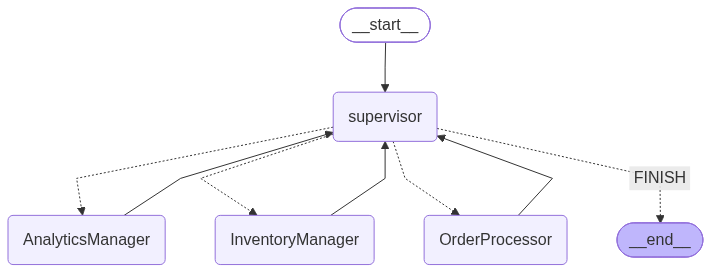

In [11]:
# Compile the graph
graph = workflow.compile()

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [12]:
from IPython.display import Markdown

# Example usage
queries = [
    "Process order ORD001 and update inventory accordingly",
    # Uncomment other queries to test different scenarios:
    # "Check all products below their reorder point and create a restock report",
    # "Analyze the top 5 selling products from the last 20 orders and visualize the results",
    # "Check if we have enough inventory to fulfill order ORD005 and process it if possible"
]

for query in queries:
    print(f"\nProcessing query: {query}")
    print("-" * 50)
    result = graph.invoke(
        {
            "messages": [
                {"role": "user", "content": query}
            ]
        }
    )
    print("\nFinal Result:")
    display(Markdown(result['messages'][-1].content))


Processing query: Process order ORD001 and update inventory accordingly
--------------------------------------------------
Invoking InventoryManager agent with state: {'messages': [{'role': 'user', 'content': 'Process order ORD001 and update inventory accordingly'}], 'next': 'InventoryManager'}

Final Result:


Inventory updated:
- Item SKU003 reduced from 5 to 2 units.
- Item SKU004 reduced from 30 to 26 units.

CONCLUSION: Inventory updated. Item SKU003 reduced from 5 to 2 units. Item SKU004 reduced from 30 to 26 units.